# Gold Recovery

For this project, I prepare a prototype of a machine learning model for Zyfra that will allow them to predict the amount of gold recovered from gold ore using data on extraction and purification. Zyfra will be able to use this model to find out which input characteristics consistently lead to low gold recovery so they can  avoid or adjust those conditions to improve efficiency and profitability.

Developing this model involves the following steps:

1. Preparing the data: I check the correctness of the data, handle missing values, and ensure the training and test sets are in good shape for model training.
2. Perform data analysis: I take a look at how the concentrations of metals change dependig on the purification stage, compare the feed particle size distributions in the training and test sets, and identify and remove by examining the total distribution of concentraions of all metals at different stages.
3. Develop and train a model: I train and test three models (Decision Tree Regression, Random Forest Regression, and Linear Regression) using symmetric Mean Absolute Percentage Error (sMAPE) as my evaluation metric and perform a final test and sanity check.


## Prepare the data

I start by importing the libraries I need.

In [46]:
# Import libraries
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyRegressor
import numpy as np
from numpy.random import RandomState
import seaborn as sns
import matplotlib.pyplot as plt

### Open the files and look into the data

Now I'll load and take a look at the data.

In [2]:
# Load datasets
gold_train = pd.read_csv('/datasets/gold_recovery_train.csv')
gold_test = pd.read_csv('/datasets/gold_recovery_test.csv')
gold_full = pd.read_csv('/datasets/gold_recovery_full.csv')

# Call info and print sample
gold_train.info()
display(gold_train.head())
print()
gold_test.info()
display(gold_test.head())
print()
gold_full.info()
display(gold_full.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64


,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5856 non-null   object 
 1   primary_cleaner.input.sulfate               5554 non-null   float64
 2   primary_cleaner.input.depressant            5572 non-null   float64
 3   primary_cleaner.input.feed_size             5856 non-null   float64
 4   primary_cleaner.input.xanthate              5690 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 10  primary_cle

,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-09-01 00:59:59,210.800909,14.993118,8.080000,1.005021,1398.981301,-500.225577,1399.144926,-499.919735,1400.102998,...,12.023554,-497.795834,8.016656,-501.289139,7.946562,-432.317850,4.872511,-500.037437,26.705889,-499.709414
1,2016-09-01 01:59:59,215.392455,14.987471,8.080000,0.990469,1398.777912,-500.057435,1398.055362,-499.778182,1396.151033,...,12.058140,-498.695773,8.130979,-499.634209,7.958270,-525.839648,4.878850,-500.162375,25.019940,-499.819438
2,2016-09-01 02:59:59,215.259946,12.884934,7.786667,0.996043,1398.493666,-500.868360,1398.860436,-499.764529,1398.075709,...,11.962366,-498.767484,8.096893,-500.827423,8.071056,-500.801673,4.905125,-499.828510,24.994862,-500.622559
3,2016-09-01 03:59:59,215.336236,12.006805,7.640000,0.863514,1399.618111,-498.863574,1397.440120,-499.211024,1400.129303,...,12.033091,-498.350935,8.074946,-499.474407,7.897085,-500.868509,4.931400,-499.963623,24.948919,-498.709987
4,2016-09-01 04:59:59,199.099327,10.682530,7.530000,0.805575,1401.268123,-500.808305,1398.128818,-499.504543,1402.172226,...,12.025367,-500.786497,8.054678,-500.397500,8.107890,-509.526725,4.957674,-500.360026,25.003331,-500.856333



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22716 entries, 0 to 22715
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                22716 non-null  object 
 1   final.output.concentrate_ag                         22627 non-null  float64
 2   final.output.concentrate_pb                         22629 non-null  float64
 3   final.output.concentrate_sol                        22331 non-null  float64
 4   final.output.concentrate_au                         22630 non-null  float64
 5   final.output.recovery                               20753 non-null  float64
 6   final.output.tail_ag                                22633 non-null  float64
 7   final.output.tail_pb                                22516 non-null  float64
 8   final.output.tail_sol                               22445 non-null  float64

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


As expected, the test set has far fewer features than the training set because some parameters were measured and/or calculated much later. There are missing values we'll need to deal with, and everything looks to be in the correct data type except the 'date' columns.

### Check that recovery is calculated correctly 

Using the training set, I calculate recovery for the rougher.output.recovery feature based on the share of gold in the concentrate and the tails. Then, I find the MAE between my calculations and the feature values.

In [3]:
# Define variables for recovery formula to find the rougher concentrate recovery
c = gold_train['rougher.output.concentrate_au']
f = gold_train['rougher.input.feed_au']
t = gold_train['rougher.output.tail_au']

# Define recovery formula
recovery_calc = (c * (f - t)) / (f * (c - t)) * 100

# Define feature value variable
actual_recovery = gold_train['rougher.output.recovery']

# Define formula to calculate MAE between calculation and feature values
mae = abs(recovery_calc - actual_recovery).mean()

# Print result
print('Mean Absolute Error:',mae)

Mean Absolute Error: 9.303415616264301e-15


The MAE is so low it is almost negligible. I can proceed with confidence that this feature value is reliable.

### Analyze the features not available in the test set 

Now, I'll dig into the parameters not available in the test set.

In [4]:
# Define columns in training set vs test set
train_columns = set(gold_train.columns)
test_columns = set(gold_test.columns)

# Identify missing columns in test set
missing_in_test = train_columns - test_columns
print("Features not in test set:", missing_in_test)

Features not in test set: {'rougher.calculation.sulfate_to_au_concentrate', 'rougher.output.concentrate_ag', 'rougher.output.tail_au', 'rougher.output.tail_sol', 'final.output.tail_ag', 'rougher.output.tail_pb', 'primary_cleaner.output.tail_pb', 'final.output.concentrate_pb', 'rougher.calculation.au_pb_ratio', 'final.output.concentrate_ag', 'primary_cleaner.output.tail_ag', 'primary_cleaner.output.concentrate_sol', 'final.output.tail_au', 'primary_cleaner.output.concentrate_pb', 'primary_cleaner.output.tail_sol', 'rougher.output.tail_ag', 'primary_cleaner.output.concentrate_ag', 'rougher.output.concentrate_au', 'secondary_cleaner.output.tail_pb', 'primary_cleaner.output.concentrate_au', 'final.output.tail_sol', 'rougher.output.recovery', 'final.output.recovery', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'secondary_cleaner.output.tail_au', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'final.output.tail_pb', 'secondary_cleaner.output.tail_sol', 'secondary_cleaner.out

The test set does not include any features for the output or calculation parameter types. This should be fine, as the model will be most useful if it can make predictions without those parameters--if they were all known, we could simply calculate the recovery. However, I do need two output features in the test set: rougher.output.recovery and final.output.recovery. These are the two target values, without which I won't be able to do a final evaluation of the model. I'll go ahead and merge these into the test set from the source set, and drop the other output and calculation parameters from the training set.

In [5]:
# Filter full source data for the target columns needed
recovery_full = gold_full[['date', 'final.output.recovery', 'rougher.output.recovery']]

# Merge into test set
gold_test_merged = pd.merge(gold_test, recovery_full, on='date', how='left')

# Display merged test set
display(gold_test_merged.head())

# Drop output and calculation columns from training set
test_merged_columns = set(gold_test_merged.columns)
missing_in_test_merged = train_columns - test_merged_columns
columns_to_drop = list(missing_in_test_merged)
print(columns_to_drop)
gold_train = gold_train.drop(columns=columns_to_drop)

# Display updated training set
display(gold_train.head())

,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,...,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level,final.output.recovery,rougher.output.recovery
0,2016-09-01 00:59:59,210.800909,14.993118,8.080000,1.005021,1398.981301,-500.225577,1399.144926,-499.919735,1400.102998,...,8.016656,-501.289139,7.946562,-432.317850,4.872511,-500.037437,26.705889,-499.709414,70.273583,89.993421
1,2016-09-01 01:59:59,215.392455,14.987471,8.080000,0.990469,1398.777912,-500.057435,1398.055362,-499.778182,1396.151033,...,8.130979,-499.634209,7.958270,-525.839648,4.878850,-500.162375,25.019940,-499.819438,68.910432,88.089657
2,2016-09-01 02:59:59,215.259946,12.884934,7.786667,0.996043,1398.493666,-500.868360,1398.860436,-499.764529,1398.075709,...,8.096893,-500.827423,8.071056,-500.801673,4.905125,-499.828510,24.994862,-500.622559,68.143213,88.412756
3,2016-09-01 03:59:59,215.336236,12.006805,7.640000,0.863514,1399.618111,-498.863574,1397.440120,-499.211024,1400.129303,...,8.074946,-499.474407,7.897085,-500.868509,4.931400,-499.963623,24.948919,-498.709987,67.776393,87.360133
4,2016-09-01 04:59:59,199.099327,10.682530,7.530000,0.805575,1401.268123,-500.808305,1398.128818,-499.504543,1402.172226,...,8.054678,-500.397500,8.107890,-509.526725,4.957674,-500.360026,25.003331,-500.856333,61.467078,83.236367


['rougher.calculation.sulfate_to_au_concentrate', 'rougher.output.concentrate_ag', 'rougher.output.tail_au', 'rougher.output.tail_sol', 'final.output.tail_ag', 'rougher.output.tail_pb', 'primary_cleaner.output.tail_pb', 'final.output.concentrate_pb', 'rougher.calculation.au_pb_ratio', 'final.output.concentrate_ag', 'primary_cleaner.output.tail_ag', 'primary_cleaner.output.concentrate_sol', 'final.output.tail_au', 'primary_cleaner.output.concentrate_pb', 'primary_cleaner.output.tail_sol', 'rougher.output.tail_ag', 'primary_cleaner.output.concentrate_ag', 'rougher.output.concentrate_au', 'secondary_cleaner.output.tail_pb', 'primary_cleaner.output.concentrate_au', 'final.output.tail_sol', 'rougher.calculation.floatbank10_sulfate_to_au_feed', 'secondary_cleaner.output.tail_au', 'rougher.calculation.floatbank11_sulfate_to_au_feed', 'final.output.tail_pb', 'secondary_cleaner.output.tail_sol', 'secondary_cleaner.output.tail_ag', 'final.output.concentrate_au', 'rougher.output.concentrate_pb', 

,date,final.output.recovery,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,70.541216,127.092003,10.128295,7.25,0.988759,1549.775757,-498.912140,1551.434204,-516.403442,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,69.266198,125.629232,10.296251,7.25,1.002663,1576.166671,-500.904965,1575.950626,-499.865889,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,68.116445,123.819808,11.316280,7.25,0.991265,1601.556163,-499.997791,1600.386685,-500.607762,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,68.347543,122.270188,11.322140,7.25,0.996739,1599.968720,-500.951778,1600.659236,-499.677094,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,66.927016,117.988169,11.913613,7.25,1.009869,1601.339707,-498.975456,1601.437854,-500.323246,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


### Perform data preprocessing

I know there are a lot of missing values from opening the files in 1.1 above. I'll need to get rid of the missing values from the training and test sets in order to train the model later on. I'll also make sure all columns are the correct data type and get rid of any duplicates.

I'll start by converting the 'date' column to datetime in all dataframes, and sorting by date.

In [6]:
# Convert date columns to datetime
gold_train['date'] = pd.to_datetime(gold_train['date'])
gold_test_merged['date'] = pd.to_datetime(gold_test_merged['date'])
gold_full['date'] = pd.to_datetime(gold_full['date'])

# Sort by date
gold_train = gold_train.sort_values(by='date').reset_index(drop=True)
gold_test_merged = gold_test_merged.sort_values(by='date').reset_index(drop=True)
gold_full = gold_full.sort_values(by='date').reset_index(drop=True)

# Display portion of training data to see how parameter values change over time
display(gold_train.head(35))

,date,final.output.recovery,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,70.541216,127.092003,10.128295,7.25,0.988759,1549.775757,-498.912140,1551.434204,-516.403442,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,69.266198,125.629232,10.296251,7.25,1.002663,1576.166671,-500.904965,1575.950626,-499.865889,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,68.116445,123.819808,11.316280,7.25,0.991265,1601.556163,-499.997791,1600.386685,-500.607762,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,68.347543,122.270188,11.322140,7.25,0.996739,1599.968720,-500.951778,1600.659236,-499.677094,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,66.927016,117.988169,11.913613,7.25,1.009869,1601.339707,-498.975456,1601.437854,-500.323246,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691
5,2016-01-15 05:00:00,69.465816,115.581252,12.470773,7.25,0.965760,1602.964922,-498.090944,1602.074298,-500.179481,...,13.938497,-500.970168,11.883350,-500.395298,10.054147,-496.374715,7.965083,-499.364752,14.017067,-599.707915
6,2016-01-15 06:00:00,69.300835,117.322323,12.469088,7.25,0.895207,1597.532455,-500.985364,1602.816321,-500.696736,...,14.046819,-500.971133,12.091543,-500.501426,10.003247,-497.083180,8.010890,-500.002423,14.029649,-600.905470
7,2016-01-15 07:00:00,70.230976,124.592960,12.467403,7.25,0.901202,1597.946266,-501.592304,1601.078254,-499.494115,...,13.974691,-501.819696,12.101324,-500.583446,9.873169,-499.171928,7.993381,-499.794518,13.984498,-600.411070
8,2016-01-15 08:00:00,69.688595,131.781026,12.465718,7.25,0.885535,1601.670053,-499.548891,1598.804355,-499.689644,...,13.964030,-504.252450,12.060738,-501.174549,10.033838,-501.178133,7.881604,-499.729434,13.967135,-599.061188
9,2016-01-15 09:00:00,70.279619,138.120409,12.464032,7.25,0.898779,1603.436598,-499.864400,1597.455353,-500.266905,...,13.989632,-503.195299,12.052233,-500.928547,9.962574,-502.986357,7.979219,-500.146835,13.981614,-598.070855


Now everything is in the correct data type. I can see that values that are next to each other in the timeline are typically similar, which will inform how I fill in the missing data. It seems reasonable to infer missing values based on how the values are increasing or decreasing over time. 

To fill in missing values, I'll start by taking a look at them and seeing if they are clustered in any pattern.

In [7]:
nan_rows_train = gold_train[gold_train.isna().any(axis=1)]
nan_rows_test = gold_test_merged[gold_test_merged.isna().any(axis=1)]
gold_train.info()
display(nan_rows_train.head(30))
gold_test_merged.info()
display(nan_rows_test.head(30))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 55 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   date                                        16860 non-null  datetime64[ns]
 1   final.output.recovery                       15339 non-null  float64       
 2   primary_cleaner.input.sulfate               15553 non-null  float64       
 3   primary_cleaner.input.depressant            15598 non-null  float64       
 4   primary_cleaner.input.feed_size             16860 non-null  float64       
 5   primary_cleaner.input.xanthate              15875 non-null  float64       
 6   primary_cleaner.state.floatbank8_a_air      16820 non-null  float64       
 7   primary_cleaner.state.floatbank8_a_level    16827 non-null  float64       
 8   primary_cleaner.state.floatbank8_b_air      16820 non-null  float64       
 9   primar

,date,final.output.recovery,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
47,2016-01-16 23:00:00,55.088448,126.397495,12.709727,7.25,1.229626,1601.301169,-498.725777,1605.370031,-500.644437,...,13.997488,-551.224653,11.971272,-550.095619,9.981163,-502.869109,7.941184,-500.623610,12.018837,-600.916665
49,2016-01-17 01:00:00,NaN,48.760868,5.021841,7.25,0.595224,1601.022931,-498.647484,1602.901368,-501.137097,...,14.032364,-549.326033,11.987133,-549.583570,10.094584,-492.041563,8.054770,-498.802262,11.961330,-597.272218
53,2016-01-17 05:00:00,71.308281,137.334448,13.944077,7.25,1.203816,1598.394630,-500.458080,1602.960131,-500.418604,...,13.972224,-548.238797,12.042964,-550.430774,9.989624,-499.606754,7.950446,-500.352648,12.011728,-599.043399
98,2016-01-19 02:00:00,58.017871,15.273131,1.940663,7.25,0.180119,1546.951271,-501.138590,1550.530280,-500.130616,...,13.947368,-703.993293,12.018188,-559.800324,9.999754,-512.673353,7.946763,-500.475471,11.963962,-607.847547
99,2016-01-19 03:00:00,NaN,2.116168,NaN,7.25,NaN,1549.052155,-500.274820,1548.147964,-500.140456,...,13.985160,-799.601232,12.036072,-603.234250,9.974968,-497.092974,7.953962,-499.698442,11.941642,-598.541756
100,2016-01-19 04:00:00,NaN,NaN,NaN,7.25,0.003844,1549.558400,-500.299753,1548.453530,-499.997415,...,14.034374,-799.600946,12.040491,-623.446329,9.898782,-499.623262,7.979302,-500.283366,11.959950,-600.998301
101,2016-01-19 05:00:00,NaN,NaN,NaN,7.25,NaN,1552.989735,-499.142241,1548.580485,-500.582886,...,13.943929,-799.600659,12.040238,-638.103348,9.956309,-499.791870,7.978806,-500.202026,11.987839,-600.302819
102,2016-01-19 06:00:00,NaN,NaN,NaN,7.25,NaN,1550.788972,-499.561168,1548.768526,-500.099996,...,14.040873,-799.600372,12.030771,-641.310327,9.966952,-499.842458,8.053455,-499.588522,11.987935,-600.523057
103,2016-01-19 07:00:00,NaN,NaN,NaN,7.25,NaN,1548.501988,-501.129966,1549.619566,-499.644217,...,13.972371,-799.600085,12.021058,-641.457227,10.033820,-501.291438,7.985956,-499.934267,12.027556,-600.108918
104,2016-01-19 08:00:00,NaN,NaN,NaN,7.25,NaN,1550.069596,-498.719368,1550.470607,-500.136229,...,13.932580,-799.599799,12.011345,-640.936879,10.004522,-500.021534,7.931758,-500.294773,12.026439,-600.301833


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 55 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   date                                        5856 non-null   datetime64[ns]
 1   primary_cleaner.input.sulfate               5554 non-null   float64       
 2   primary_cleaner.input.depressant            5572 non-null   float64       
 3   primary_cleaner.input.feed_size             5856 non-null   float64       
 4   primary_cleaner.input.xanthate              5690 non-null   float64       
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64       
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64       
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64       
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64       
 9   primary_

,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,...,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level,final.output.recovery,rougher.output.recovery
30,2016-09-02 06:59:59,NaN,NaN,7.160000,NaN,412.629243,-795.316337,413.703253,-787.396567,441.604260,...,4.625908,-678.347958,4.451592,-795.337422,3.544708,-800.024373,5.914889,-799.501783,0.000000,0.000000
31,2016-09-02 07:59:59,5.039223,NaN,7.160000,NaN,1436.850397,-542.923353,1549.140548,-528.601849,1548.664773,...,7.967571,-527.714564,8.191769,-517.004063,4.906812,-531.125899,10.002271,-527.901468,NaN,NaN
32,2016-09-02 08:59:59,0.857926,NaN,7.160000,NaN,1435.627557,-499.752988,1550.871908,-500.348180,1513.760138,...,7.988670,-501.212454,8.067387,-501.622580,5.067141,-499.295523,9.989370,-500.350093,NaN,NaN
33,2016-09-02 09:59:59,24.616337,0.600245,7.160000,0.196905,1437.685689,-498.718550,1549.223455,-498.417613,1510.244855,...,8.061677,-495.442389,8.079009,-495.166033,5.171338,-479.361256,10.056638,-498.991980,NaN,46.824320
34,2016-09-02 10:59:59,64.558863,0.061864,7.109500,0.520084,1433.954958,-499.688476,1553.150053,-500.878552,1517.894908,...,8.129055,-500.125308,8.031323,-486.756657,5.047491,-467.938124,10.047098,-499.813489,96.148407,65.817436
35,2016-09-02 11:59:59,112.768923,6.061414,6.150000,0.819723,1426.909049,-500.749720,1544.540348,-501.570124,1509.087281,...,8.100986,-501.032511,8.053520,-506.002857,5.025161,-447.918397,9.911242,-497.922919,56.440734,71.035116
36,2016-09-02 12:59:59,132.526641,8.257739,6.671500,0.803072,1419.081952,-499.519835,1530.869084,-499.749240,1494.243228,...,8.075180,-500.466176,8.077882,-509.265467,4.837108,-501.855340,9.891463,-504.150985,58.476088,76.785779
37,2016-09-02 13:59:59,138.109389,7.975929,7.640000,0.800642,1420.088768,-499.765691,1522.047015,-499.458234,1483.131191,...,8.049423,-500.135072,7.905382,-503.020886,4.925342,-500.552419,10.045443,-500.501492,57.269791,73.364628
38,2016-09-02 14:59:59,137.468356,8.033932,7.631500,0.795075,1420.541569,-499.448089,1521.031586,-500.215288,1480.336556,...,8.023665,-499.915658,8.032640,-499.111977,5.001865,-499.479137,9.965626,-499.557170,60.503503,80.024002
39,2016-09-02 15:59:59,142.640808,7.994107,7.630000,0.710677,1416.369505,-499.720730,1520.391160,-499.610693,1477.798629,...,7.997908,-500.176428,8.030963,-502.125537,4.998390,-499.594847,10.019014,-500.020957,62.820117,80.122435


Every column aside from 'date' is missing some data, but most are missing less than 5%. There's no clear pattern for the missing data, so I'll assume it's missing at random.

The rougher.output.recovery and final.output.recovery columns are missing values in both the training and test sets, but these are the target columns so I can't impute the missing values without affecting how the model learns. It's best to delete missing values for these columns. 

In [8]:
# Drop rows with NaNs in target columns for gold_train
gold_train = gold_train.dropna(subset=['rougher.output.recovery', 'final.output.recovery'])

# Drop rows with NaNs in target columns for gold_test_merged
gold_test_merged = gold_test_merged.dropna(subset=['rougher.output.recovery', 'final.output.recovery'])

For the feature columns, I'll use spline interpolation to impute the missing data because I can see that the parameters are following a pattern over time, but the pattern is complex. Values can increase for a few hours, then decrease, and then increase again. Cubic spline interpolation will provide a flexible approximation of the complex patterns.

In [9]:
# Apply cubic spline interpolation only to numeric columns in the training set
gold_train_numeric = gold_train.drop(columns=['date']).interpolate(method='spline', order=3)

# Reattach the date column
gold_train = pd.concat([gold_train[['date']].reset_index(drop=True), gold_train_numeric.reset_index(drop=True)], axis=1)

# Check for remaining missing values
print('Remaining NaNs in training set:', gold_train.isna().sum().sum())

# Apply cubic spline interpolation only to numeric columns in the test set
gold_test_numeric = gold_test_merged.drop(columns=['date']).interpolate(method='spline', order=3)

# Reattach the date column
gold_test_merged = pd.concat([gold_test_merged[['date']].reset_index(drop=True), gold_test_numeric.reset_index(drop=True)], axis=1)

# Check for remaining missing values
print('Remaining NaNs in test set:', gold_test_merged.isna().sum().sum())

Remaining NaNs in training set: 0
Remaining NaNs in test set: 0


Now that there are no more missing values, I'll check for any duplicate rows.

In [10]:
# Check for duplicates in gold_train
duplicates_train = gold_train.duplicated().sum()
print(f"Duplicate rows in gold_train: {duplicates_train}")

# Check for duplicates in gold_test_merged
duplicates_test = gold_test_merged.duplicated().sum()
print(f"Duplicate rows in gold_test_merged: {duplicates_test}")

# Check for duplicates in gold_full
duplicates_full = gold_full.duplicated().sum()
print(f"Duplicate rows in gold_full: {duplicates_full}")

Duplicate rows in gold_train: 0
Duplicate rows in gold_test_merged: 0
Duplicate rows in gold_full: 0


There are no duplicate rows, so I'll move forward on analyzing the data.

## Analyze the data

In this step, I'll do some exploratory data analysis to understand how the concentrations of gold, silver, and lead change depending on the purification stage. I'll also make sure the feed particle distributions are similar in the training and test sets, and identify and remove any abnormal values in the total distribution of the concentrations of all substances at different stages.

### Take note of how the concentrations of metals (Au, Ag, Pb) change depending on the purification stage

To understand how the concentrations of gold, silver, and lead change depending on the purification stage, I'll plot histograms to show the distribution of metal percentages by stage.

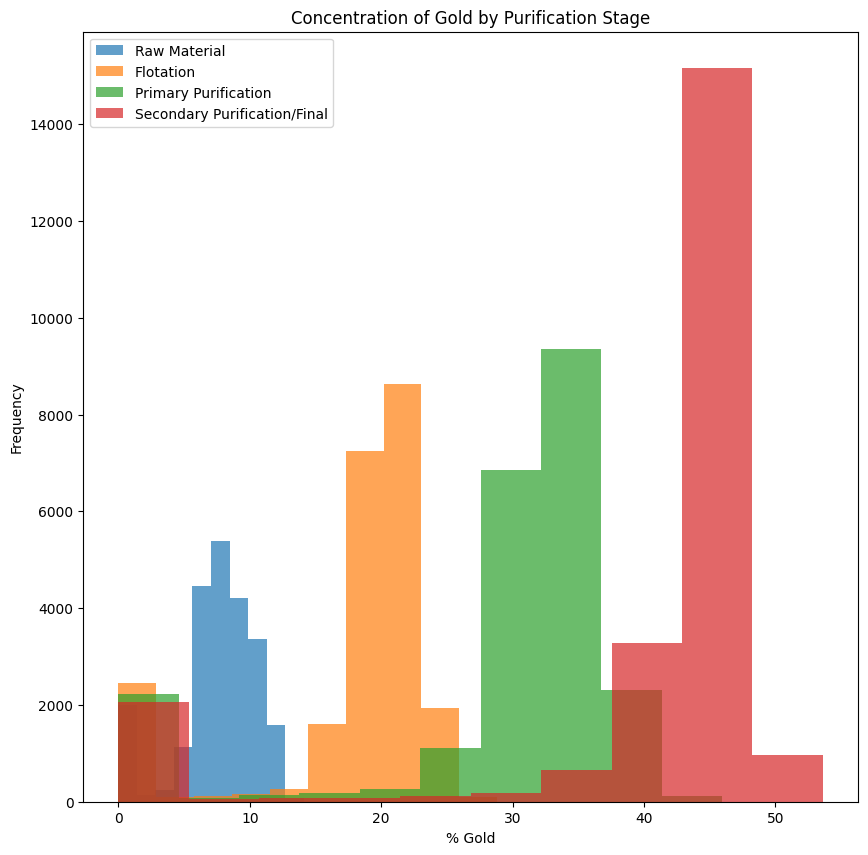

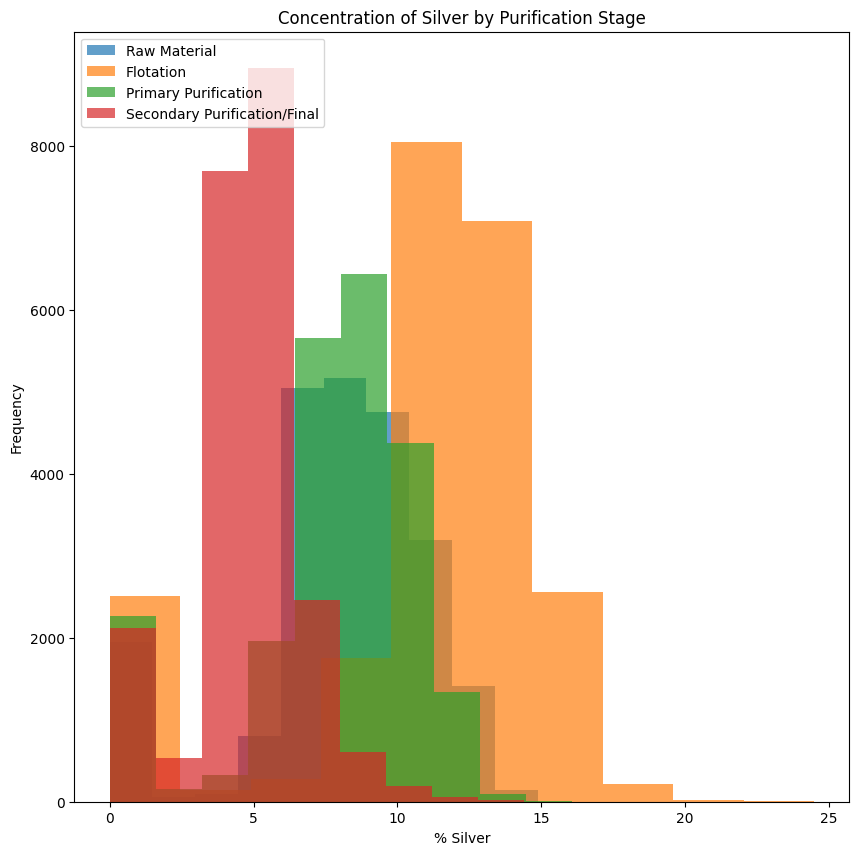

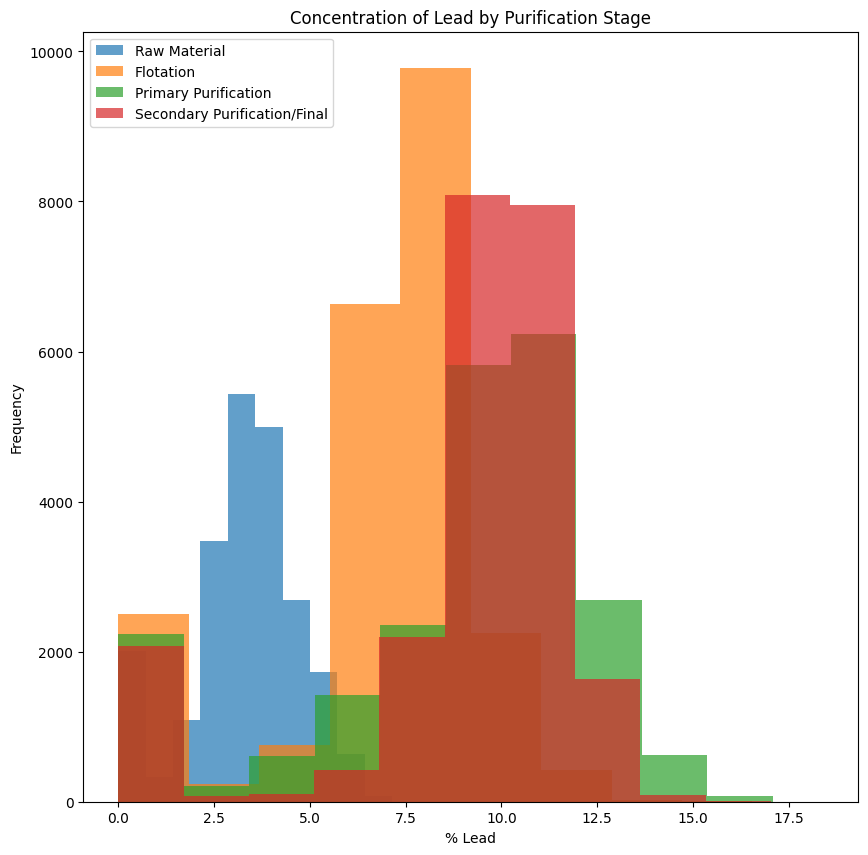

In [11]:
# Create dataframes for each metal showing concentrations at each stage
concentration_au = gold_full[['rougher.input.feed_au', 'rougher.output.concentrate_au', 'primary_cleaner.output.concentrate_au', 'final.output.concentrate_au']]
concentration_ag = gold_full[['rougher.input.feed_ag', 'rougher.output.concentrate_ag', 'primary_cleaner.output.concentrate_ag', 'final.output.concentrate_ag']]
concentration_pb = gold_full[['rougher.input.feed_pb', 'rougher.output.concentrate_pb', 'primary_cleaner.output.concentrate_pb', 'final.output.concentrate_pb']]

# Plot histograms for each metal

fig = plt.figure(figsize=(10, 10))

plt.hist(concentration_au['rougher.input.feed_au'], alpha=0.7, label='Raw Material')
plt.hist(concentration_au['rougher.output.concentrate_au'], alpha=0.7, label='Flotation')
plt.hist(concentration_au['primary_cleaner.output.concentrate_au'], alpha=0.7, label='Primary Purification')
plt.hist(concentration_au['final.output.concentrate_au'], alpha=0.7, label='Secondary Purification/Final')

plt.xlabel('% Gold')
plt.ylabel('Frequency')
plt.legend(loc='upper left')
plt.title('Concentration of Gold by Purification Stage')
plt.show()

fig = plt.figure(figsize=(10, 10))

plt.hist(concentration_ag['rougher.input.feed_ag'], alpha=0.7, label='Raw Material')
plt.hist(concentration_ag['rougher.output.concentrate_ag'], alpha=0.7, label='Flotation')
plt.hist(concentration_ag['primary_cleaner.output.concentrate_ag'], alpha=0.7, label='Primary Purification')
plt.hist(concentration_ag['final.output.concentrate_ag'], alpha=0.7, label='Secondary Purification/Final')

plt.xlabel('% Silver')
plt.ylabel('Frequency')
plt.legend(loc='upper left')
plt.title('Concentration of Silver by Purification Stage')
plt.show()

fig = plt.figure(figsize=(10, 10))

plt.hist(concentration_pb['rougher.input.feed_pb'], alpha=0.7, label='Raw Material')
plt.hist(concentration_pb['rougher.output.concentrate_pb'], alpha=0.7, label='Flotation')
plt.hist(concentration_pb['primary_cleaner.output.concentrate_pb'], alpha=0.7, label='Primary Purification')
plt.hist(concentration_pb['final.output.concentrate_pb'], alpha=0.7, label='Secondary Purification/Final')

plt.xlabel('% Lead')
plt.ylabel('Frequency')
plt.legend(loc='upper left')
plt.title('Concentration of Lead by Purification Stage')
plt.show()

For gold, I can see that the concentration generally increases at each purification stage, which make sense as this is the goal of the ore purification process. Silver increases after flotation and then decreases, showing that the later purification stages are more effective at filtering it out. Lead seems to increase slightly and then stagnate, mostly commonly measured at a 10% concentration in the final stage. Despite many stages of purification, small amounts of silver and lead typically remain in the final concentrate.

Additionally, all three metals seem to have more than 2,000 occurences of a concentration of 0% across several stages. I'll examine that further in 2.3 below.

### Compare the feed particle size distributions in the training set and in the test set

To compare the feed particle size distributions in the training set vs. the test set, I'll use KDE plots to visualize the distribution density for primary_cleaner.input.feed_size and rougher.input.feed_size values. This will allow for effective comparison without being affected by different sample sizes. If the distributions vary significantly, the model evaluation will be incorrect.

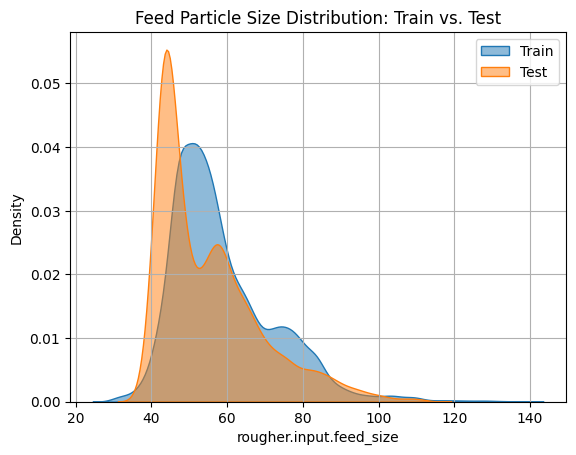

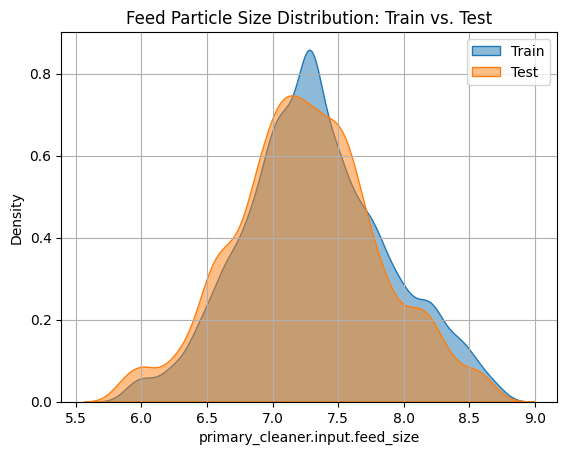

In [15]:
# Define function to filter out outliers
def filter_outliers(series):
    return series[(series >= series.quantile(0.01)) & (series <= series.quantile(0.99))]

# Define function to plot KDE plots
def compare_train_test_feature(feature):
    sns.kdeplot(filter_outliers(gold_train[feature]), label='Train', fill=True, alpha=0.5)
    sns.kdeplot(filter_outliers(gold_test_merged[feature]), label='Test', fill=True, alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.title(f'Feed Particle Size Distribution: Train vs. Test')
    plt.legend()
    plt.grid(True)

    plt.show()

# Plot rougher input feed size
compare_train_test_feature('rougher.input.feed_size')
# Plot primary cleaner feed size
compare_train_test_feature('primary_cleaner.input.feed_size')

Based on these visualizations, the distributions look fairly similar. The feed particle size distribution for the raw material differs a bit more than at the primary purification stage in terms of spread and peak, but raw material looks slightly right-skewed for both sets and both show the bulk of values between 40 and 60. This shouldn't impact the model accuracy too much.

### Consider the total concentrations of all substances at different stages

Now I'll plot histograms to show the total concentration of all metals at the raw, flotation, primary purification, and final stages (using the full source data). If there are any abnormal values, it might be worth removing them.

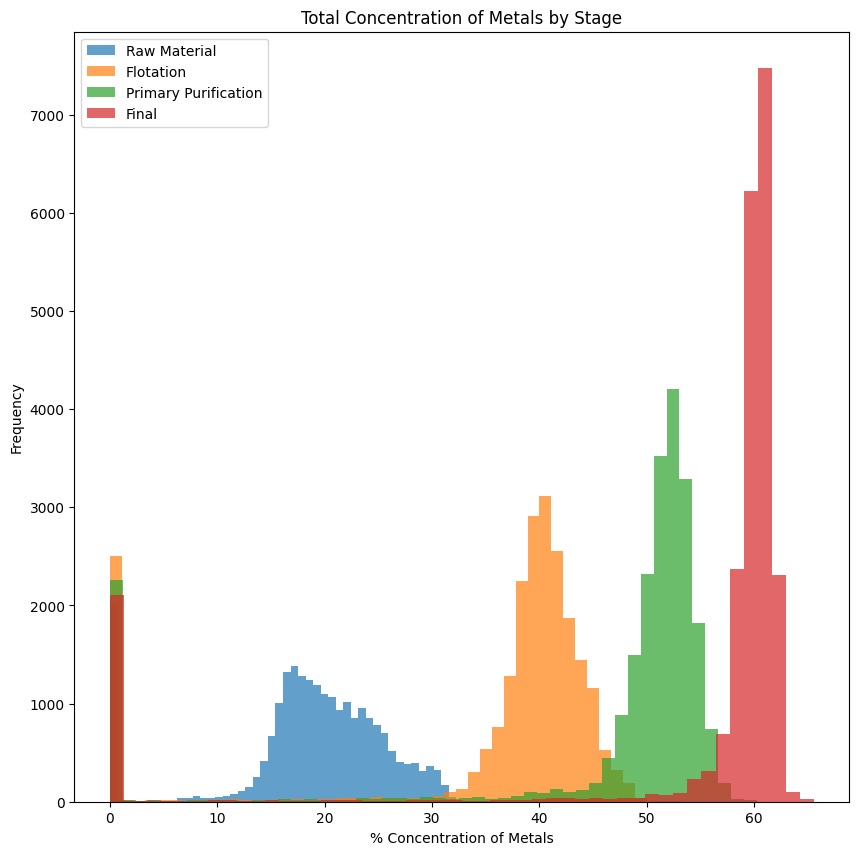

In [19]:
# Define list of metals
metals = ['au', 'ag', 'pb']

# Define function to sum concentrations of all metals
def total_concentration(stage):
    return gold_full[[f"{stage}_{metal}" for metal in metals]].sum(axis=1)

# Plot distribution of totals at each stage
fig = plt.figure(figsize=(10, 10))
plt.hist(total_concentration('rougher.input.feed'), alpha=.7, bins=50, label='Raw Material')
plt.hist(total_concentration('rougher.output.concentrate'), alpha=.7, bins=50, label='Flotation')
plt.hist(total_concentration('primary_cleaner.output.concentrate'), alpha=.7, bins=50, label='Primary Purification')
plt.hist(total_concentration('final.output.concentrate'), alpha=.7, bins=50, label='Final')

plt.legend(loc='upper left')
plt.xlabel('% Concentration of Metals')
plt.ylabel('Frequency')
plt.title('Total Concentration of Metals by Stage')
plt.show()  

Looks like the zero values that showed up in the plots for each metal above are in the same rows, suggesting these are probably errors. It's best to remove these observations from the training and test sets.

In [20]:
# Filter out rows where the total concentration of metals is 0 for any stage
gold_full_drop = gold_full[
    (total_concentration('rougher.input.feed') == 0) |
    (total_concentration('rougher.output.concentrate') == 0) |
    (total_concentration('primary_cleaner.output.concentrate') == 0) |
    (total_concentration('final.output.concentrate') == 0)
]

# Get the set of dates to drop
dates_to_drop = gold_full_drop['date']

# Filter out rows with those dates in gold_train
gold_train = gold_train[~gold_train['date'].isin(dates_to_drop)]

# Filter out rows with those dates in gold_test_merged
gold_test_merged = gold_test_merged[~gold_test_merged['date'].isin(dates_to_drop)]

Now it's time to train the model.

## Build the model

I'll train and evaluate three models: Decision Tree Regression, Random Forest Regression, and Linear Regression. To evaluate these models, I'll calculate the symmetric Mean Absolute Percentage Error or sMAPE of the model predictions for both target values (rougher.output.recovery and final.output.recovery). I'll need to write a function to calculate sMAPE. The best model will be the one with the lowest sMAPE.

First, I'll split the data into features and targets and scale the features.

In [22]:
# Create features and targets for training and test sets
features_train = gold_train.drop(columns=['date', 'rougher.output.recovery', 'final.output.recovery'])
target_train = gold_train[['rougher.output.recovery', 'final.output.recovery']]

features_test = gold_test_merged.drop(columns=['date', 'rougher.output.recovery', 'final.output.recovery'])
target_test = gold_test_merged[['rougher.output.recovery', 'final.output.recovery']]

# Scale features for Linear Regression model
scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train)
features_test_scaled = scaler.transform(features_test)
features_train_scaled = pd.DataFrame(features_train_scaled, columns=features_train.columns, index=features_train.index)
features_test_scaled = pd.DataFrame(features_test_scaled, columns=features_test.columns, index=features_test.index)

### Write a function to calculate the final sMAPE value.

Now I'll define a function for sMAPE, which can then be used as the model scorer.

In [36]:
# Define function to calculate sMAPE
def smape(target, prediction):
    return 100/len(target) * np.sum(2 * np.abs(prediction - target) / (np.abs(target) + np.abs(prediction)))

# Define function to calculate final sMAPE
def final_smape(targets, predictions):
    rougher = smape(targets.iloc[:, 0], predictions[:,0])
    final = smape(targets.iloc[:,1], predictions[:,1])
    return .25 * rougher + .75 * final

# Integrate as a custom scorer in sklearn
smape_score = make_scorer(final_smape, greater_is_better=False)

### Train different models

It's time to traing the models, evaluate them using cross-validation, and pick the best model. 

First, I'll train and evaluate a Decision Tree Regression model.

In [37]:
# Train model
model_dt = DecisionTreeRegressor(max_depth=5, random_state=12345)
model_dt.fit(features_train, target_train)
predictions = model_dt.predict(features_train)

# Evaluate using cross-validation
scores_dt = cross_val_score(model_dt, features_train, target_train, cv=5, scoring=smape_score)

# Print mean score, reversing negative value due to greater_is_better parameter
print('Decision Tree Final sMAPE:',-scores_dt.mean())

Decision Tree Final sMAPE: 9.798635521527896


Next I'll look at a Random Forest Regression model.

In [38]:
# Train model
model_rf = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=12345)
model_rf.fit(features_train, target_train)
predictions = model_rf.predict(features_train)

# Evaluate using cross-validation
scores_rf = cross_val_score(model_rf, features_train, target_train, cv=5, scoring=smape_score)

# Print mean score
print('Random Forest Final sMAPE:',-scores_rf.mean())

Random Forest Final sMAPE: 8.868795086220622


The Random Forest is performing a bit better than the Decision Tree. Finally, I'll train a Linear Regression model.

In [40]:
# Train model, using scaled features
model_lr = LinearRegression()
model_lr.fit(features_train_scaled, target_train)
predictions = model_lr.predict(features_train_scaled)

# Evaluate using cross-validation
scores_lr = cross_val_score(model_lr, features_train_scaled, target_train, cv=5, scoring=smape_score)

# Print mean score
print('Linear Regression Final sMAPE:',-scores_lr.mean())

Linear Regression Final sMAPE: 11.550435822911378


Of the three models, the Random Forest is performing the best with the lowest sMAPE score. Next I'll explore if tuning hyperparamters can yield an even lower sMAPE score.

In [44]:
# Define random state
state = np.random.RandomState(12345)

# Initialize model
best_rf = RandomForestRegressor(random_state=state)

# Define parameters
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=best_rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring=smape_score)

# Fit grid search to training set
grid_search.fit(features_train, target_train)

# Print best score
print('Best sMAPE Score:', -grid_search.best_score_)

# Print best hyperparameters
print('Best Hyperparameters:', grid_search.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   8.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   8.1s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   8.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   8.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   8.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  16.1s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  16.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  15.9s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=  15.8s
[CV] END max_depth=5, min_samples_leaf=1, m

[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  27.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  28.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=  28.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time=  42.7s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time=  42.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time=  41.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time=  42.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=150; total time=  42.5s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=50; total time=  14.2s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=2, n_estimators=50; total time=

[CV] END max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time=  18.5s
[CV] END max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time=  18.5s
[CV] END max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time=  17.7s
[CV] END max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time=  18.0s
[CV] END max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time=  18.3s
[CV] END max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  36.8s
[CV] END max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  37.0s
[CV] END max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  35.2s
[CV] END max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  35.7s
[CV] END max_depth=15, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  3

Hyperparameter tuning did not improve the sMAPE score. I'll proceed with Random Forest as the best model and evaluate it on the test set.

In [45]:
# Run model on test set
predictions_test = model_rf.predict(features_test)

# Print final sMAPE score on test set
print('Test Set Final sMAPE:', final_smape(target_test, predictions_test))

Test Set Final sMAPE: 7.620496477758399


The model performs even better on the test set while still yielding a fairly close score, which further builds confidence that it's not overfitted. As a final step, I'll sanity check our model by seeing if it performs better than a naive baseline. To do this, I'll look at the sMAPE score of a Dummy Regression model that always predicts the mean and the median.

In [47]:
# Build and train dummy models
model_mean = DummyRegressor(strategy='mean')
model_mean.fit(features_train, target_train)
predictions_mean = model_mean.predict(features_test)

model_med = DummyRegressor(strategy='median')
model_med.fit(features_train, target_train)
predictions_med = model_med.predict(features_test)

# Print sMAPE scores
print('Mean Baseline Final sMAPE:', final_smape(target_test, predictions_mean))
print('Median Baseline Final sMAPE:', final_smape(target_test, predictions_mean))

Mean Baseline Final sMAPE: 7.77808938006563
Median Baseline Final sMAPE: 7.77808938006563


The model is performing slightly better than the baseline.

## Conclusion

In this project, I developed a machine learning prototype for Zyfra to predict gold recovery rates using input and process data. By deploying this model, Zyfra can:

* Simulate different production scenarios to identify unprofitable operational conditions;

* Avoid wasting resources on processing raw material with unprofitable input characteristics; and

* Improve decision-making in real-time by predicting outcomes before adjusting production parameters.

The Random Forest Regression model demonstrated the best performance, achieving a final symmetric Mean Absolute Percentage Error (sMAPE) of 7.6% on the test set. This indicates a high level of predictive accuracy. The sanity checks confirmed that the model outperforms simple baseline models. However, the model only outperformed the baseline by .15%.

While prototype establishes a strong foundation for integrating predictive analytics into Zyfra’s production processes, it is worth exploring further improvements by continuously updating the model with new data or exploring other model types.